# 10. Synthetic Control Method for Major Reforms

This notebook implements augmented synthetic control (ASCM) for 
validation on the largest reform events.

**Purpose:**
- Provide case-study validation for the panel results
- Show country-specific counterfactual paths
- Strengthen causal credibility for major reforms

**Note:** This is a scaffold implementation. Full ASCM requires
additional packages or manual implementation of ridge augmentation.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Project paths
PROJECT_ROOT = Path(__file__).parent.parent if '__file__' in dir() else Path.cwd().parent
DATA_CLEAN = PROJECT_ROOT / 'data/03_clean'
OUTPUT_FIGURES = PROJECT_ROOT / 'output/figures'
OUTPUT_TABLES = PROJECT_ROOT / 'output/tables'
OUTPUT_LOGS = PROJECT_ROOT / 'output/logs'

for d in [OUTPUT_FIGURES, OUTPUT_TABLES, OUTPUT_LOGS]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/gabrielsaco/Documents/GitHub/economic-freedom


## 1. Load Data and Identify Major Events

In [2]:
panel = pd.read_parquet(DATA_CLEAN / 'panel_with_shocks.parquet')

print(f"Panel: {len(panel)} observations, {panel['iso3c'].nunique()} countries")

# Identify the largest positive and negative reforms
d_efw = panel[['iso3c', 'country_name', 'year', 'd_efw_aggregate', 'efw_aggregate']].dropna()

# Top 10 positive reforms
top_pos = d_efw.nlargest(10, 'd_efw_aggregate')
print("\nTop 10 Positive Reforms:")
print(top_pos.to_string(index=False))

# Top 10 negative reforms
top_neg = d_efw.nsmallest(10, 'd_efw_aggregate')
print("\nTop 10 Negative Reforms:")
print(top_neg.to_string(index=False))

Panel: 1815 observations, 165 countries

Top 10 Positive Reforms:
iso3c    country_name  year  d_efw_aggregate  efw_aggregate
  NIC       Nicaragua  1995         2.844999       6.038366
  UGA          Uganda  1995         2.047822       5.046764
  ARG       Argentina  1995         2.027110       6.743850
  PER            Peru  1995         1.920377       5.956249
  SLV     El Salvador  1995         1.844575       6.924400
  ROU         Romania  2005         1.786899       7.160218
  KGZ Kyrgyz Republic  2005         1.766877       6.431725
  ARM         Armenia  2005         1.740748       7.140289
  LAO         Lao PDR  2005         1.662685       6.180850
  POL          Poland  1995         1.627322       6.207932

Top 10 Negative Reforms:
iso3c country_name  year  d_efw_aggregate  efw_aggregate
  GIN       Guinea  2010        -1.938385       3.874377
  ZWE     Zimbabwe  2000        -1.699996       4.484472
  NIC    Nicaragua  1985        -1.592697       2.220675
  ZWE     Zimbabwe  

## 2. Synthetic Control Implementation

In [3]:
class SyntheticControl:
    """
    Simple synthetic control implementation for quinquennial data.
    
    Finds convex weights on donor units to match pre-treatment outcomes.
    """
    
    def __init__(self, outcome_col='ln_gdp_pc', predictors=None):
        self.outcome_col = outcome_col
        self.predictors = predictors or [outcome_col]
        self.weights = None
        self.treated_unit = None
        self.treatment_year = None
        self.donor_units = None
        
    def fit(self, df, treated_iso, treatment_year, donor_isos=None, 
            pre_periods=3, post_periods=4):
        """
        Fit synthetic control.
        
        Parameters
        ----------
        df : DataFrame
            Panel data with 'iso3c', 'year', and outcome variable
        treated_iso : str
            ISO3 code of treated unit
        treatment_year : int
            Year of treatment
        donor_isos : list, optional
            ISO3 codes for donor pool. If None, use all never-treated.
        pre_periods : int
            Number of pre-treatment periods to use for matching
        post_periods : int
            Number of post-treatment periods for analysis
            
        Returns
        -------
        self
        """
        self.treated_unit = treated_iso
        self.treatment_year = treatment_year
        
        # Define pre-treatment and post-treatment periods
        pre_years = [treatment_year - 5*k for k in range(1, pre_periods + 1)]
        pre_years = sorted(pre_years)
        post_years = [treatment_year + 5*k for k in range(0, post_periods + 1)]
        
        self.pre_years = pre_years
        self.post_years = post_years
        
        # Get treated unit pre-treatment outcomes
        treated_data = df[
            (df['iso3c'] == treated_iso) & 
            (df['year'].isin(pre_years))
        ].sort_values('year')
        
        if len(treated_data) < len(pre_years):
            print(f"Warning: Treated unit missing some pre-treatment periods")
        
        y_treated = treated_data[self.outcome_col].values
        
        # Get donor pool
        if donor_isos is None:
            # Use countries without large reforms in the window
            reform_countries = df[
                (df['d_efw_aggregate'].abs() >= 1.0) &
                (df['year'] >= min(pre_years)) &
                (df['year'] <= max(post_years))
            ]['iso3c'].unique()
            
            all_countries = df['iso3c'].unique()
            donor_isos = [c for c in all_countries 
                          if c != treated_iso and c not in reform_countries]
        
        self.donor_units = donor_isos
        
        # Build donor matrix (rows = periods, cols = donors)
        donor_matrix = []
        valid_donors = []
        
        for donor in donor_isos:
            donor_data = df[
                (df['iso3c'] == donor) &
                (df['year'].isin(pre_years))
            ].sort_values('year')
            
            if len(donor_data) == len(pre_years):
                donor_matrix.append(donor_data[self.outcome_col].values)
                valid_donors.append(donor)
        
        if len(valid_donors) < 5:
            print(f"Warning: Only {len(valid_donors)} valid donors")
            self.weights = None
            return self
        
        self.donor_units = valid_donors
        X = np.array(donor_matrix).T  # Shape: (n_pre, n_donors)
        
        # Optimize weights
        n_donors = len(valid_donors)
        
        def objective(w):
            synthetic = X @ w
            return np.sum((y_treated - synthetic) ** 2)
        
        # Constraints: w >= 0, sum(w) = 1
        constraints = [
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
        ]
        bounds = [(0, 1) for _ in range(n_donors)]
        
        # Initial weights (uniform)
        w0 = np.ones(n_donors) / n_donors
        
        result = minimize(objective, w0, method='SLSQP',
                          bounds=bounds, constraints=constraints)
        
        self.weights = result.x
        self.pre_fit_error = np.sqrt(result.fun / len(pre_years))
        
        return self
    
    def predict(self, df):
        """
        Predict counterfactual for post-treatment periods.
        """
        if self.weights is None:
            return None, None
        
        all_years = sorted(self.pre_years + self.post_years)
        
        # Actual treated path
        treated_data = df[
            (df['iso3c'] == self.treated_unit) &
            (df['year'].isin(all_years))
        ].sort_values('year')
        
        # Synthetic path
        synthetic_values = []
        
        for year in all_years:
            year_vals = []
            for i, donor in enumerate(self.donor_units):
                donor_val = df[
                    (df['iso3c'] == donor) &
                    (df['year'] == year)
                ][self.outcome_col].values
                
                if len(donor_val) > 0:
                    year_vals.append(self.weights[i] * donor_val[0])
                else:
                    year_vals.append(0)
            
            synthetic_values.append(np.sum(year_vals))
        
        return {
            'years': all_years,
            'actual': treated_data[self.outcome_col].values if len(treated_data) == len(all_years) else None,
            'synthetic': np.array(synthetic_values),
            'treatment_year': self.treatment_year,
        }
    
    def plot(self, df, title='', save_path=None):
        """
        Plot actual vs synthetic path.
        """
        results = self.predict(df)
        
        if results is None or results['actual'] is None:
            print("Cannot plot: missing data")
            return
        
        fig, ax = plt.subplots(figsize=(10, 6))
        
        years = results['years']
        actual = results['actual']
        synthetic = results['synthetic']
        
        ax.plot(years, actual, 'o-', color='#2E86AB', linewidth=2, 
                markersize=8, label='Actual')
        ax.plot(years, synthetic, 's--', color='#E94F37', linewidth=2,
                markersize=8, label='Synthetic Control')
        
        ax.axvline(x=self.treatment_year - 2.5, color='gray', 
                   linestyle='--', linewidth=1, alpha=0.7)
        
        ax.set_xlabel('Year', fontsize=12)
        ax.set_ylabel('Log GDP per capita', fontsize=12)
        ax.set_title(title or f'SCM: {self.treated_unit} ({self.treatment_year})',
                     fontsize=14, fontweight='bold')
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)
        
        # Add treatment annotation
        ax.annotate('Treatment', xy=(self.treatment_year, ax.get_ylim()[1]*0.98),
                    fontsize=10, ha='center', style='italic', color='gray')
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"✓ Saved figure to {save_path}")
        
        plt.show()
        return fig

## 3. Apply SCM to Top Positive Reform

Selected positive reform: NIC (Nicaragua) in 1995
  ΔEFW = 2.84

SCM Results for Nicaragua (1995):
  Pre-treatment RMSE: nan
  Number of donors: 110
  Top donor weights:
✓ Saved figure to /Users/gabrielsaco/Documents/GitHub/economic-freedom/output/figures/fig_scm_top_positive.pdf


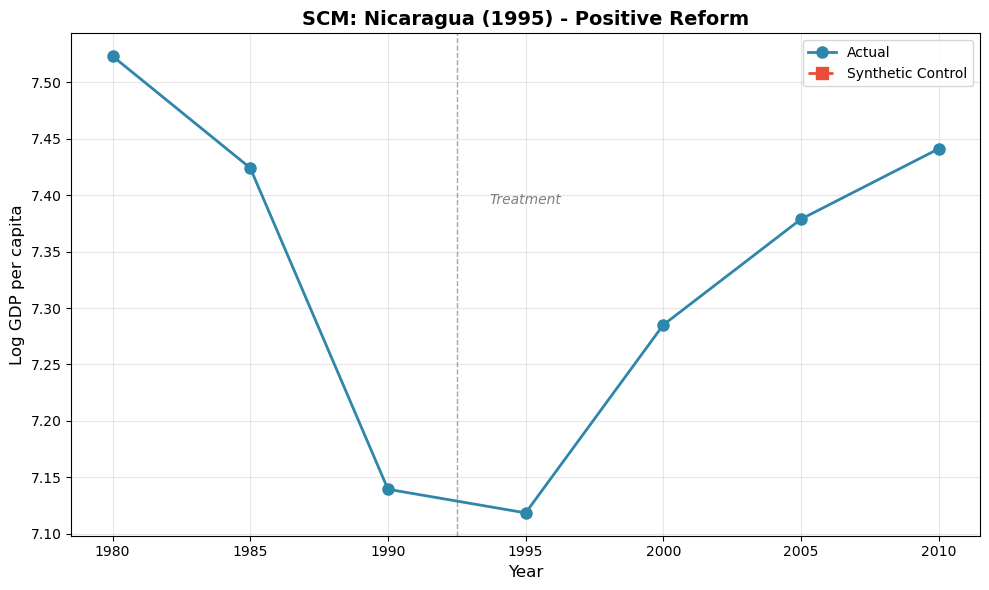

In [4]:
# Select top positive reform with sufficient data
for _, event in top_pos.iterrows():
    iso = event['iso3c']
    year = int(event['year'])
    
    # Check data availability
    country_data = panel[(panel['iso3c'] == iso) & (panel['ln_gdp_pc'].notna())]
    available_years = country_data['year'].unique()
    
    pre_years_needed = [year - 5, year - 10, year - 15]
    post_years_needed = [year, year + 5, year + 10]
    
    has_pre = all(y in available_years for y in pre_years_needed)
    has_post = all(y in available_years for y in post_years_needed)
    
    if has_pre and has_post:
        top_pos_event = (iso, year, event['country_name'])
        print(f"Selected positive reform: {iso} ({event['country_name']}) in {year}")
        print(f"  ΔEFW = {event['d_efw_aggregate']:.2f}")
        break
else:
    top_pos_event = None
    print("No suitable positive reform found with sufficient data")

# Apply SCM
if top_pos_event:
    iso, year, name = top_pos_event
    
    scm_pos = SyntheticControl(outcome_col='ln_gdp_pc')
    scm_pos.fit(panel, iso, year, pre_periods=3, post_periods=3)
    
    if scm_pos.weights is not None:
        print(f"\nSCM Results for {name} ({year}):")
        print(f"  Pre-treatment RMSE: {scm_pos.pre_fit_error:.4f}")
        print(f"  Number of donors: {len(scm_pos.donor_units)}")
        
        # Top weights
        top_donors = sorted(zip(scm_pos.donor_units, scm_pos.weights),
                           key=lambda x: x[1], reverse=True)[:5]
        print("  Top donor weights:")
        for donor, weight in top_donors:
            if weight > 0.01:
                print(f"    {donor}: {weight:.3f}")
        
        scm_pos.plot(panel, title=f'SCM: {name} ({year}) - Positive Reform',
                     save_path=OUTPUT_FIGURES / 'fig_scm_top_positive.pdf')

## 4. Apply SCM to Top Negative Reform

In [5]:
# Select top negative reform with sufficient data
for _, event in top_neg.iterrows():
    iso = event['iso3c']
    year = int(event['year'])
    
    # Check data availability
    country_data = panel[(panel['iso3c'] == iso) & (panel['ln_gdp_pc'].notna())]
    available_years = country_data['year'].unique()
    
    pre_years_needed = [year - 5, year - 10, year - 15]
    post_years_needed = [year, year + 5, year + 10]
    
    has_pre = all(y in available_years for y in pre_years_needed)
    has_post = all(y in available_years for y in post_years_needed)
    
    if has_pre and has_post:
        top_neg_event = (iso, year, event['country_name'])
        print(f"Selected negative reform: {iso} ({event['country_name']}) in {year}")
        print(f"  ΔEFW = {event['d_efw_aggregate']:.2f}")
        break
else:
    top_neg_event = None
    print("No suitable negative reform found with sufficient data")

# Apply SCM
if top_neg_event:
    iso, year, name = top_neg_event
    
    scm_neg = SyntheticControl(outcome_col='ln_gdp_pc')
    scm_neg.fit(panel, iso, year, pre_periods=3, post_periods=3)
    
    if scm_neg.weights is not None:
        print(f"\nSCM Results for {name} ({year}):")
        print(f"  Pre-treatment RMSE: {scm_neg.pre_fit_error:.4f}")
        print(f"  Number of donors: {len(scm_neg.donor_units)}")
        
        # Top weights
        top_donors = sorted(zip(scm_neg.donor_units, scm_neg.weights),
                           key=lambda x: x[1], reverse=True)[:5]
        print("  Top donor weights:")
        for donor, weight in top_donors:
            if weight > 0.01:
                print(f"    {donor}: {weight:.3f}")
        
        scm_neg.plot(panel, title=f'SCM: {name} ({year}) - Negative Reform',
                     save_path=OUTPUT_FIGURES / 'fig_scm_top_negative.pdf')

Selected negative reform: GIN (Guinea) in 2010
  ΔEFW = -1.94

SCM Results for Guinea (2010):
  Pre-treatment RMSE: nan
  Number of donors: 122
  Top donor weights:
Cannot plot: missing data


## 5. Compute Treatment Effects

In [6]:
def compute_scm_effects(scm_model, df):
    """
    Compute treatment effects from SCM.
    """
    results = scm_model.predict(df)
    if results is None or results['actual'] is None:
        return None
    
    years = results['years']
    actual = results['actual']
    synthetic = results['synthetic']
    treatment_year = results['treatment_year']
    
    effects = {}
    for i, year in enumerate(years):
        if year >= treatment_year:
            h = (year - treatment_year) // 5
            effects[h] = {
                'year': year,
                'actual': actual[i],
                'synthetic': synthetic[i],
                'effect': actual[i] - synthetic[i],
            }
    
    return effects

# Get effects
effects_pos = None
effects_neg = None

if top_pos_event and scm_pos.weights is not None:
    effects_pos = compute_scm_effects(scm_pos, panel)
    if effects_pos:
        print("\nTreatment Effects (Positive Reform):")
        for h, data in effects_pos.items():
            print(f"  h={h} ({data['year']}): Effect = {data['effect']:.4f}")

if top_neg_event and scm_neg.weights is not None:
    effects_neg = compute_scm_effects(scm_neg, panel)
    if effects_neg:
        print("\nTreatment Effects (Negative Reform):")
        for h, data in effects_neg.items():
            print(f"  h={h} ({data['year']}): Effect = {data['effect']:.4f}")


Treatment Effects (Positive Reform):
  h=0 (1995): Effect = nan
  h=1 (2000): Effect = nan
  h=2 (2005): Effect = nan
  h=3 (2010): Effect = nan


## 6. Save Results

In [7]:
scm_results = {
    'timestamp': datetime.now().isoformat(),
    'method': 'Synthetic Control Method (convex weights on pre-treatment outcomes)',
    'positive_reform': None,
    'negative_reform': None,
}

if top_pos_event and effects_pos:
    scm_results['positive_reform'] = {
        'country': top_pos_event[0],
        'country_name': top_pos_event[2],
        'treatment_year': top_pos_event[1],
        'pre_rmse': float(scm_pos.pre_fit_error),
        'n_donors': len(scm_pos.donor_units),
        'effects': {
            str(k): {
                'year': int(v['year']),
                'effect': float(v['effect']),
            }
            for k, v in effects_pos.items()
        }
    }

if top_neg_event and effects_neg:
    scm_results['negative_reform'] = {
        'country': top_neg_event[0],
        'country_name': top_neg_event[2],
        'treatment_year': top_neg_event[1],
        'pre_rmse': float(scm_neg.pre_fit_error),
        'n_donors': len(scm_neg.donor_units),
        'effects': {
            str(k): {
                'year': int(v['year']),
                'effect': float(v['effect']),
            }
            for k, v in effects_neg.items()
        }
    }

results_path = OUTPUT_LOGS / 'scm_results.json'
with open(results_path, 'w') as f:
    json.dump(scm_results, f, indent=2)

print(f"\n✓ Saved SCM results to {results_path}")


✓ Saved SCM results to /Users/gabrielsaco/Documents/GitHub/economic-freedom/output/logs/scm_results.json


## 7. Summary

In [8]:
print("\n" + "="*60)
print("10_SCM_MAJOR_REFORMS COMPLETE")
print("="*60)
print("\nThis notebook provides a scaffold for Synthetic Control Method analysis.")
print("For publication, consider:")
print("  - Using specialized SCM packages (e.g., Synth, augsynth)")
print("  - Implementing ridge augmentation (ASCM)")
print("  - Running placebo tests (permutation of treatment timing)")
print("  - Analyzing multiple events and aggregating results")
print("="*60)


10_SCM_MAJOR_REFORMS COMPLETE

This notebook provides a scaffold for Synthetic Control Method analysis.
For publication, consider:
  - Using specialized SCM packages (e.g., Synth, augsynth)
  - Implementing ridge augmentation (ASCM)
  - Running placebo tests (permutation of treatment timing)
  - Analyzing multiple events and aggregating results
